In [1]:
import numpy as np
import random

class GridWorld:
    def __init__(self, rows=5, cols=5, start=(0, 0), goal=(4, 4), obstacles=None):
        self.rows = rows
        self.cols = cols
        self.start = start
        self.goal = goal
        self.obstacles = set(obstacles or [])
        self.actions = {
            0: (-1, 0),  # Up
            1: (1, 0),   # Down
            2: (0, -1),  # Left
            3: (0, 1)    # Right
        }
        self.reset()

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        dr, dc = self.actions[action]
        r, c = self.state
        nr, nc = r + dr, c + dc

        # boundary check
        if nr < 0 or nr >= self.rows or nc < 0 or nc >= self.cols:
            return self.state, -5, False

        next_state = (nr, nc)

        # obstacle
        if next_state in self.obstacles:
            return self.state, -10, False

        # goal
        if next_state == self.goal:
            self.state = next_state
            return next_state, 100, True

        self.state = next_state
        return next_state, -1, False


def state_to_index(state, cols):
    return state[0] * cols + state[1]


def choose_action(q_table, state_idx, epsilon, n_actions):
    if random.random() < epsilon:
        return random.randint(0, n_actions - 1)
    return int(np.argmax(q_table[state_idx]))


def train_q_learning(env, episodes=500, alpha=0.1, gamma=0.95,
                     epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995):
    n_states = env.rows * env.cols
    n_actions = len(env.actions)
    q_table = np.zeros((n_states, n_actions))
    episode_rewards = []

    for ep in range(episodes):
        state = env.reset()
        state_idx = state_to_index(state, env.cols)
        total_reward = 0

        for _ in range(200):
            action = choose_action(q_table, state_idx, epsilon, n_actions)
            next_state, reward, done = env.step(action)
            next_state_idx = state_to_index(next_state, env.cols)

            q_table[state_idx, action] = q_table[state_idx, action] + alpha * (
                reward + gamma * np.max(q_table[next_state_idx]) - q_table[state_idx, action]
            )

            state_idx = next_state_idx
            total_reward += reward

            if done:
                break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)

    return q_table, episode_rewards


if __name__ == "__main__":
    obstacles = [(1, 1), (1, 2), (2, 1), (3, 3)]
    env = GridWorld(rows=5, cols=5, start=(0, 0), goal=(4, 4), obstacles=obstacles)

    q_table, rewards = train_q_learning(env, episodes=500)

    print("Trained Q-table:")
    print(q_table)

    # Test learned policy
    state = env.reset()
    path = [state]
    for _ in range(30):
        idx = state_to_index(state, env.cols)
        action = int(np.argmax(q_table[idx]))
        next_state, reward, done = env.step(action)
        path.append(next_state)
        state = next_state
        if done:
            break

    print("\nLearned path:")
    print(path)

Trained Q-table:
[[ 52.33071475  63.80047553  54.91210727  52.28729212]
 [  7.85355508  13.28329305  58.92014075   9.45324023]
 [ -0.99371997  -4.44475675  -0.27508274  19.04102152]
 [  5.47325801  18.27581512   0.22637138  34.09018091]
 [ 16.57147146  51.06225278  10.39644023  14.87322543]
 [ 55.23628285  68.21102687  57.63184369  53.54219224]
 [  0.           0.           0.           0.        ]
 [  0.           0.           0.           0.        ]
 [  4.28789106  26.37198123  10.81889232  48.0340121 ]
 [ 22.8685378   72.0872136   24.14475656  33.05286257]
 [ 62.03593562  72.8537125   63.93358663  58.81174461]
 [  0.           0.           0.           0.        ]
 [ 12.95835182  56.78891338   7.60594541  28.94388825]
 [ 18.58910922  15.90646193  14.12165409  66.16716193]
 [ 36.50833077  88.60310004  31.6438018   40.97980555]
 [ 67.50963632  77.74075     67.96038907  76.69740926]
 [ 62.79299454  82.87841669  56.10150071  64.32277286]
 [ 36.93137942  87.92582826  56.80990541  51.073

True probabilities: [0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75]
ε-greedy estimated Q: [0.17142857 0.24657534 0.32352941 0.46987952 0.68       0.73394495
 0.74481836]
ε-greedy arm counts: [ 105.   73.   68.   83.   75.  109. 4487.]
UCB estimated Q: [0.14285714 0.27358491 0.36423841 0.46280992 0.54773869 0.65792031
 0.7340213 ]
UCB arm counts: [  70.  106.  151.  242.  398. 1029. 3004.]


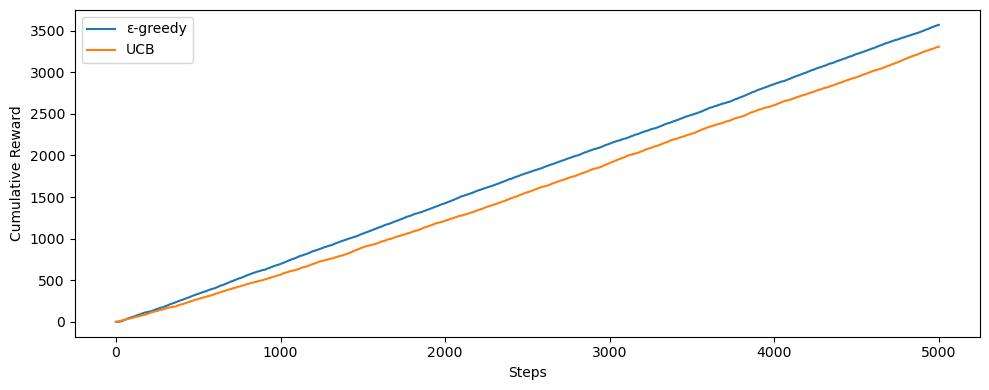

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

class KArmedBandit:
    def __init__(self, probabilities):
        self.probabilities = np.array(probabilities)
        self.k = len(probabilities)

    def pull(self, arm):
        return 1 if np.random.rand() < self.probabilities[arm] else 0


def epsilon_greedy_bandit(env, steps=5000, epsilon=0.1):
    k = env.k
    Q = np.zeros(k)
    N = np.zeros(k)
    rewards = []
    arm_counts = np.zeros(k)

    for t in range(steps):
        if np.random.rand() < epsilon:
            arm = np.random.randint(k)
        else:
            arm = np.argmax(Q)

        reward = env.pull(arm)
        N[arm] += 1
        arm_counts[arm] += 1
        Q[arm] += (reward - Q[arm]) / N[arm]
        rewards.append(reward)

    return Q, rewards, arm_counts


def ucb_bandit(env, steps=5000, c=2):
    k = env.k
    Q = np.zeros(k)
    N = np.zeros(k)
    rewards = []
    arm_counts = np.zeros(k)

    # pull each arm once
    for arm in range(k):
        reward = env.pull(arm)
        N[arm] += 1
        arm_counts[arm] += 1
        Q[arm] += (reward - Q[arm]) / N[arm]
        rewards.append(reward)

    for t in range(k, steps):
        ucb_values = np.zeros(k)
        for arm in range(k):
            ucb_values[arm] = Q[arm] + c * np.sqrt(np.log(t + 1) / N[arm])

        arm = np.argmax(ucb_values)
        reward = env.pull(arm)
        N[arm] += 1
        arm_counts[arm] += 1
        Q[arm] += (reward - Q[arm]) / N[arm]
        rewards.append(reward)

    return Q, rewards, arm_counts


if __name__ == "__main__":
    probabilities = [0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75]
    env = KArmedBandit(probabilities)

    Q_eps, rewards_eps, counts_eps = epsilon_greedy_bandit(env, steps=5000, epsilon=0.1)
    Q_ucb, rewards_ucb, counts_ucb = ucb_bandit(env, steps=5000, c=2)

    print("True probabilities:", probabilities)
    print("ε-greedy estimated Q:", Q_eps)
    print("ε-greedy arm counts:", counts_eps)
    print("UCB estimated Q:", Q_ucb)
    print("UCB arm counts:", counts_ucb)

    plt.figure(figsize=(10, 4))
    plt.plot(np.cumsum(rewards_eps), label="ε-greedy")
    plt.plot(np.cumsum(rewards_ucb), label="UCB")
    plt.xlabel("Steps")
    plt.ylabel("Cumulative Reward")
    plt.legend()
    plt.tight_layout()
    plt.show()

Episode 100: Reward = 27.0, Epsilon = 0.606
Episode 200: Reward = 14.0, Epsilon = 0.367
Episode 300: Reward = 19.0, Epsilon = 0.222
Episode 400: Reward = 13.0, Epsilon = 0.135
Episode 500: Reward = 12.0, Epsilon = 0.082
Episode 600: Reward = 56.0, Epsilon = 0.050
Episode 700: Reward = 34.0, Epsilon = 0.050
Episode 800: Reward = 34.0, Epsilon = 0.050
Episode 900: Reward = 33.0, Epsilon = 0.050
Episode 1000: Reward = 21.0, Epsilon = 0.050


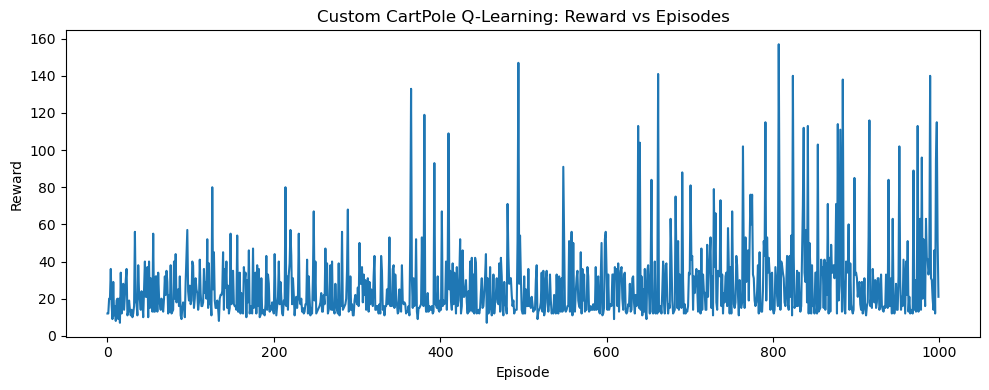

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

class CustomCartPole:
    def __init__(self):
        # Physics constants
        self.gravity = 9.8
        self.masscart = 1.0
        self.masspole = 0.1
        self.total_mass = self.masscart + self.masspole
        self.length = 0.5  # half pole length
        self.polemass_length = self.masspole * self.length
        self.force_mag = 10.0
        self.tau = 0.02

        # Failure limits
        self.x_threshold = 2.4
        self.theta_threshold_radians = 12 * np.pi / 180

        self.state = None
        self.reset()

    def reset(self):
        self.state = np.random.uniform(low=-0.05, high=0.05, size=(4,))
        return self.state.copy()

    def step(self, action):
        x, x_dot, theta, theta_dot = self.state

        force = self.force_mag if action == 1 else -self.force_mag
        costheta = np.cos(theta)
        sintheta = np.sin(theta)

        temp = (force + self.polemass_length * theta_dot**2 * sintheta) / self.total_mass
        thetaacc = (self.gravity * sintheta - costheta * temp) / (
            self.length * (4.0/3.0 - self.masspole * costheta**2 / self.total_mass)
        )
        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass

        # Euler integration
        x = x + self.tau * x_dot
        x_dot = x_dot + self.tau * xacc
        theta = theta + self.tau * theta_dot
        theta_dot = theta_dot + self.tau * thetaacc

        self.state = np.array([x, x_dot, theta, theta_dot])

        done = (
            x < -self.x_threshold or x > self.x_threshold or
            theta < -self.theta_threshold_radians or theta > self.theta_threshold_radians
        )

        reward = 1.0 if not done else 0.0
        return self.state.copy(), reward, done


class Discretizer:
    def __init__(self, bins):
        self.bins = bins

    def discretize(self, obs):
        x, x_dot, theta, theta_dot = obs

        x_bins = np.linspace(-2.4, 2.4, self.bins[0] - 1)
        x_dot_bins = np.linspace(-3.0, 3.0, self.bins[1] - 1)
        theta_bins = np.linspace(-0.2095, 0.2095, self.bins[2] - 1)
        theta_dot_bins = np.linspace(-3.5, 3.5, self.bins[3] - 1)

        return (
            np.digitize(x, x_bins),
            np.digitize(x_dot, x_dot_bins),
            np.digitize(theta, theta_bins),
            np.digitize(theta_dot, theta_dot_bins),
        )


def state_to_index(state, bins):
    idx = 0
    for i, s in enumerate(state):
        mult = 1
        for b in bins[i + 1:]:
            mult *= b
        idx += s * mult
    return idx


def choose_action(q_table, state_idx, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(q_table.shape[1])
    return int(np.argmax(q_table[state_idx]))


def train_cartpole_qlearning(episodes=1000):
    env = CustomCartPole()
    bins = (6, 6, 12, 12)
    discretizer = Discretizer(bins)

    n_states = bins[0] * bins[1] * bins[2] * bins[3]
    n_actions = 2
    q_table = np.zeros((n_states, n_actions))

    alpha = 0.1
    gamma = 0.99
    epsilon = 1.0
    epsilon_min = 0.05
    epsilon_decay = 0.995

    episode_rewards = []

    for ep in range(episodes):
        obs = env.reset()
        state = discretizer.discretize(obs)
        state_idx = state_to_index(state, bins)
        total_reward = 0

        for _ in range(500):
            action = choose_action(q_table, state_idx, epsilon)
            next_obs, reward, done = env.step(action)
            next_state = discretizer.discretize(next_obs)
            next_state_idx = state_to_index(next_state, bins)

            q_table[state_idx, action] += alpha * (
                reward + gamma * np.max(q_table[next_state_idx]) - q_table[state_idx, action]
            )

            state_idx = next_state_idx
            total_reward += reward

            if done:
                break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)

        if (ep + 1) % 100 == 0:
            print(f"Episode {ep+1}: Reward = {total_reward}, Epsilon = {epsilon:.3f}")

    return q_table, episode_rewards


if __name__ == "__main__":
    q_table, rewards = train_cartpole_qlearning(episodes=1000)

    plt.figure(figsize=(10, 4))
    plt.plot(rewards)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("Custom CartPole Q-Learning: Reward vs Episodes")
    plt.tight_layout()
    plt.show()

In [5]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

class TrafficIntersection:
    def __init__(self, max_queue=10):
        self.max_queue = max_queue
        self.reset()

    def reset(self):
        # queues: [north, south, east, west]
        self.queues = [0, 0, 0, 0]
        return tuple(self.queues)

    def step(self, action):
        """
        action:
        0 -> green for north-south
        1 -> green for east-west
        """
        # random arrivals
        arrivals = [np.random.poisson(1.5) for _ in range(4)]
        self.queues = [min(self.max_queue, q + a) for q, a in zip(self.queues, arrivals)]

        # vehicles pass through green lanes
        if action == 0:
            # north and south move
            self.queues[0] = max(0, self.queues[0] - 2)
            self.queues[1] = max(0, self.queues[1] - 2)
        else:
            # east and west move
            self.queues[2] = max(0, self.queues[2] - 2)
            self.queues[3] = max(0, self.queues[3] - 2)

        total_waiting = sum(self.queues)
        reward = -total_waiting
        throughput = sum(arrivals)  # approximate throughput measure
        next_state = tuple(self.queues)
        return next_state, reward, throughput


def discretize_state(state, cap=10):
    # cap each queue length to reduce state space
    return tuple(min(q, cap) for q in state)


def state_to_index(state, base=11):
    # state is 4 queue lengths, each in [0..10]
    idx = 0
    for q in state:
        idx = idx * base + q
    return idx


def choose_action(q_table, state_idx, epsilon):
    if random.random() < epsilon:
        return random.randint(0, 1)
    return int(np.argmax(q_table[state_idx]))


def train_traffic_q_learning(episodes=500, steps_per_episode=200):
    env = TrafficIntersection(max_queue=10)
    n_states = 11 ** 4
    n_actions = 2
    q_table = np.zeros((n_states, n_actions))

    alpha = 0.1
    gamma = 0.95
    epsilon = 1.0
    epsilon_min = 0.05
    epsilon_decay = 0.995

    avg_waiting_times = []
    throughputs = []

    for ep in range(episodes):
        state = env.reset()
        total_waiting = 0
        total_throughput = 0

        for _ in range(steps_per_episode):
            ds = discretize_state(state)
            s_idx = state_to_index(ds)

            action = choose_action(q_table, s_idx, epsilon)
            next_state, reward, throughput = env.step(action)
            next_ds = discretize_state(next_state)
            next_idx = state_to_index(next_ds)

            q_table[s_idx, action] += alpha * (
                reward + gamma * np.max(q_table[next_idx]) - q_table[s_idx, action]
            )

            state = next_state
            total_waiting += sum(state)
            total_throughput += throughput

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        avg_waiting_times.append(total_waiting / steps_per_episode)
        throughputs.append(total_throughput)

        if (ep + 1) % 50 == 0:
            print(f"Episode {ep+1}: Avg waiting = {avg_waiting_times[-1]:.2f}, Throughput = {throughputs[-1]}")

    return q_table, avg_waiting_times, throughputs


if __name__ == "__main__":
    q_table, avg_waiting_times, throughputs = train_traffic_q_learning()

    print("\nTraining completed.")
    print("Final average waiting time:", avg_waiting_times[-1])
    print("Final throughput:", throughputs[-1])

Episode 50: Avg waiting = 28.18, Throughput = 1172
Episode 100: Avg waiting = 29.45, Throughput = 1195
Episode 150: Avg waiting = 29.45, Throughput = 1213
Episode 200: Avg waiting = 29.47, Throughput = 1212
Episode 250: Avg waiting = 28.64, Throughput = 1210
Episode 300: Avg waiting = 27.95, Throughput = 1151
Episode 350: Avg waiting = 28.66, Throughput = 1216
Episode 400: Avg waiting = 27.16, Throughput = 1177
Episode 450: Avg waiting = 27.62, Throughput = 1178
Episode 500: Avg waiting = 28.68, Throughput = 1220

Training completed.
Final average waiting time: 28.68
Final throughput: 1220


In [6]:
def bayes_single_symptom(p_disease, p_symptom_given_disease, p_symptom_given_no_disease):
    p_no_disease = 1 - p_disease
    p_symptom = (p_symptom_given_disease * p_disease) + (p_symptom_given_no_disease * p_no_disease)
    if p_symptom == 0:
        return 0.0
    posterior = (p_symptom_given_disease * p_disease) / p_symptom
    return posterior


def bayes_multiple_symptoms(p_disease, symptoms_probs):
    """
    symptoms_probs = [
        (P(S1|D), P(S1|~D)),
        (P(S2|D), P(S2|~D)),
        ...
    ]
    Assumes conditional independence of symptoms given disease status.
    """
    p_no_disease = 1 - p_disease

    p_symptoms_given_disease = 1.0
    p_symptoms_given_no_disease = 1.0

    for p_s_given_d, p_s_given_not_d in symptoms_probs:
        p_symptoms_given_disease *= p_s_given_d
        p_symptoms_given_no_disease *= p_s_given_not_d

    numerator = p_symptoms_given_disease * p_disease
    denominator = numerator + (p_symptoms_given_no_disease * p_no_disease)

    if denominator == 0:
        return 0.0

    posterior = numerator / denominator
    return posterior


def classify_disease(posterior, threshold=0.5):
    return "Disease present" if posterior > threshold else "Disease absent"


if __name__ == "__main__":
    print("Single symptom diagnosis")
    p_disease = float(input("Enter P(Disease): "))
    p_s_given_d = float(input("Enter P(Symptom | Disease): "))
    p_s_given_not_d = float(input("Enter P(Symptom | ¬Disease): "))

    posterior = bayes_single_symptom(p_disease, p_s_given_d, p_s_given_not_d)
    print(f"P(Disease | Symptom) = {posterior:.4f}")
    print(classify_disease(posterior, threshold=0.5))

    print("\nMultiple symptom diagnosis")
    n = int(input("How many symptoms? "))
    symptoms_probs = []

    for i in range(n):
        print(f"Symptom {i+1}:")
        p1 = float(input("  P(Symptom | Disease): "))
        p2 = float(input("  P(Symptom | ¬Disease): "))
        symptoms_probs.append((p1, p2))

    posterior_multi = bayes_multiple_symptoms(p_disease, symptoms_probs)
    print(f"P(Disease | Symptoms) = {posterior_multi:.4f}")
    print(classify_disease(posterior_multi, threshold=0.5))

Single symptom diagnosis


Enter P(Disease):  0.4
Enter P(Symptom | Disease):  0.3
Enter P(Symptom | ¬Disease):  0.7


P(Disease | Symptom) = 0.2222
Disease absent

Multiple symptom diagnosis


How many symptoms?  4


Symptom 1:


...

Symptom 3:


  P(Symptom | Disease):  0.6
  P(Symptom | ¬Disease):  0.4


Symptom 4:


  P(Symptom | Disease):  0.3
  P(Symptom | ¬Disease):  0.7


P(Disease | Symptoms) = 0.6000
Disease present
